In [46]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
import os

In [47]:
data_dir = "/content/drive/MyDrive/datamites/Internship/PRCP-1001-RiceLeaf/Data"

In [48]:
img_size = (224,224) # height and width in pixels
batch_size = 16  # model process 16 images at a time

# Image data Generator ( EDA + Augmentation )

In [49]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
)


# Training data  --> For learning (adjusting weights)
train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='training'
)


# Validation data --> For checking performance during training
val_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='validation'
)

# Purpose:
# Augmentation artificially increases dataset size → reduces overfitting → better generalization.

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


# Display Sample Images - EDA

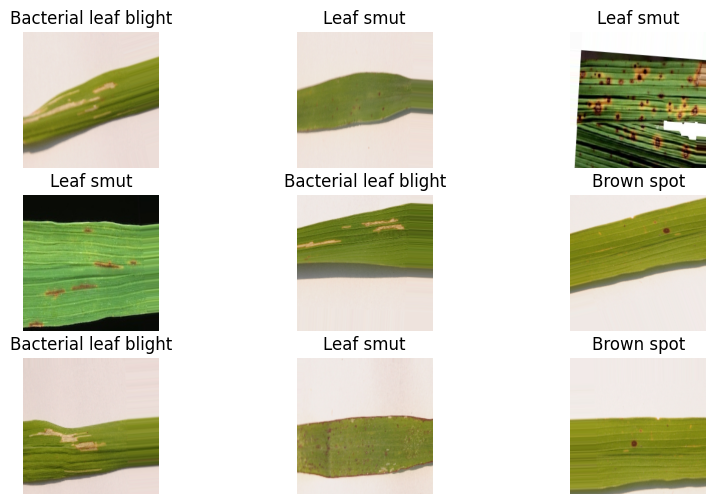

In [50]:
class_names = list(train_gen.class_indices.keys())

plt.figure(figsize=(10,6))
for i in range(9):
    img, label = next(train_gen)
    plt.subplot(3, 3, i+1)
    plt.imshow(img[0])
    plt.title(class_names[np.argmax(label[0])])
    plt.axis("off")
plt.show()

# Build Model Using MobileNetV2

#### Why MobileNetV2?
#### Lightweight
#### Fast
#### Very high accuracy on small datasets
#### Uses pretrained ImageNet features → you don’t need to train from scratch

In [51]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3)) # imagenet --> MobileNetV2, trained on ImageNet (14 million images) no need from scratch

base_model.trainable = False  # freeze layers
# 2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 0.7717 - loss: 0.5375
# Validation Accuracy:  0.782608687877655

x = base_model.output

# converting feature map into single long vector
x = GlobalAveragePooling2D()(x)

# randomly dropping 30% of neurons during training
# x = Dropout(0.3)(x)
x = Dropout(0.5)(x)

prediction = Dense(3, activation='softmax')(x) # 3 --> total_n_classes

model = Model(inputs  = base_model.input,
              outputs = prediction
              )

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train The Model

In [52]:
#  for optimizing accuracy

history = model.fit(
    train_gen,
    epochs=20, # 20 epoch the model see all the images 20 times (each tiime improves the weights)
    validation_data=val_gen,

)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.3558 - loss: 1.6944 - val_accuracy: 0.4783 - val_loss: 1.0263
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3807 - loss: 1.5169 - val_accuracy: 0.5652 - val_loss: 0.9251
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5458 - loss: 1.2424 - val_accuracy: 0.6957 - val_loss: 0.7000
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6128 - loss: 0.9687 - val_accuracy: 0.6522 - val_loss: 0.8472
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5726 - loss: 0.8729 - val_accuracy: 0.7826 - val_loss: 0.5567
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6284 - loss: 0.8972 - val_accuracy: 0.7826 - val_loss: 0.4695
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6247 - loss: 0.7641 - val_accuracy: 0.7826 - val_loss: 0.6011
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6470 - loss: 0.7314 - val_accuracy: 0.8261 - val_loss: 0.5217
Epoch 9/20
6/6 

# Plot Accuracy and Loss

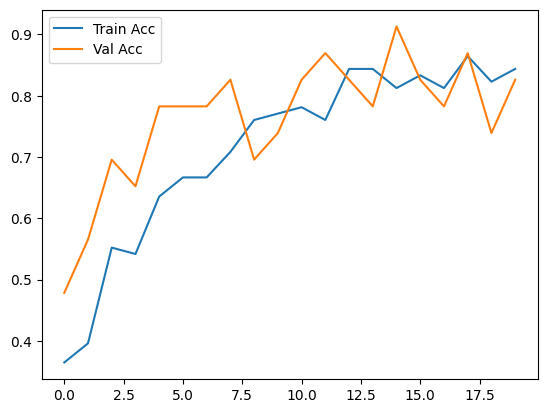

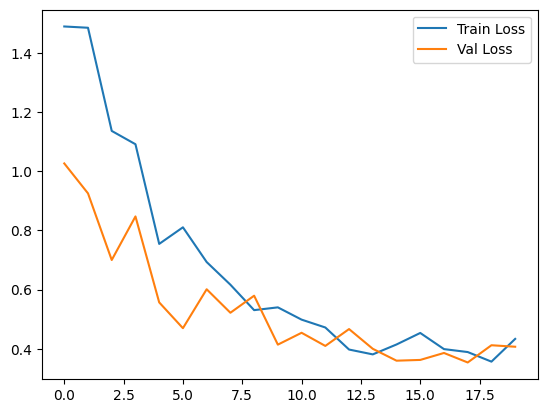

In [53]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

#### Loss decreasing → learning working

#### Validation loss close to training loss → model generalizing

#### Validation loss increasing → overfitting

# Evaluate


In [54]:
val_loss , val_acc = model.evaluate(val_gen)
print("Validation Accuracy: ",val_acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.7717 - loss: 0.4525
Validation Accuracy:  0.782608687877655


The MobileNetV2 transfer learning model achieved a strong performance with a training accuracy of ~77% and a validation accuracy of ~78%.
The validation curve closely follows the training curve, indicating that the model did not overfit significantly.
Data augmentation helped improve generalization, especially with a small dataset of only 120 images.

How to Write this in Challenges & Solutions

What You Should Do Next (Important)**

# Save The Model

In [55]:
model.save("rice_lef_cnn.h5")